# 03 — Baseline Model (Linear Regression)

**Objective:** Train a simple Linear Regression model to predict `ClosePrice`  
and establish a **baseline R² score** that future models must beat.

**What is Linear Regression?**  
It draws the best-fit straight line through the data.  
The formula is: `ClosePrice = w1*LivingArea + w2*Bedrooms + ... + bias`  
where the model learns the weights (w1, w2, etc.) from the training data.

## 1 — Imports

In [43]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 2 — Load the Cleaned Data

We load the `train.csv` and `test.csv` files created in `02_preprocessing.ipynb`.  
These already have missing values filled, categories encoded, and numeric features scaled.

In [44]:
# Load train and test data
# Resolve project root (parent of Notebooks/) using absolute paths
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..')) if os.path.basename(NOTEBOOK_DIR) == 'Notebooks' else NOTEBOOK_DIR
DATA_DIR = os.path.join(PROJECT_ROOT, 'Cleaned, Test, Train Data')

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f'Training set: {len(train_df):,} rows')
print(f'Test set:     {len(test_df):,} rows')
train_df.head()

Training set: 379,894 rows
Test set:     24,379 rows


,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,GarageSpaces,Stories,DaysOnMarket,City,PostalCode,ClosePrice
0,0.770183,0.591032,1.437598,-0.016636,1.495259,0.001813,-0.656594,0.064578,158,384,2499999.0
1,0.109317,-0.492992,0.442197,-0.017383,1.165229,-0.263071,-0.656594,-0.403606,511,535,640000.0
2,-0.920486,-0.492992,-0.553204,-0.016896,-0.558262,0.001813,-0.656594,-0.598682,339,525,438000.0
3,0.024266,-1.577015,-0.553204,-0.017181,1.091889,0.001813,-0.656594,0.922914,172,471,615000.0
4,-0.635452,-0.492992,-0.553204,-0.016724,1.678609,0.001813,-0.656594,0.571777,765,3642,399990.0


## 3 — Separate Features (X) and Target (y)

- **X** = the input features the model uses to make predictions
- **y** = the target value (`ClosePrice`) the model is trying to predict

**Note on Categorical Features:** `City` and `PostalCode` were label-encoded into arbitrary integers in Notebook 02.  
Because Linear Regression assumes numeric inputs have a natural order (e.g. 100 is larger than 10), raw label-encoded IDs  
distort linear calculations across 1,100+ cities. We exclude `City` and `PostalCode` here so Linear Regression evaluates strictly  
on physical property features (`LivingArea`, `Bedrooms`, `LotSize`, etc.).  
*(We handle categorical location features properly via Target Encoding in Notebook 05!)*

In [45]:
# The target column we want to predict
target = 'ClosePrice'

# Exclude target as well as LabelEncoded categoricals (City, PostalCode) which confuse Linear Regression
drop_cols = [target, 'City', 'PostalCode']

X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
y_train = train_df[target]

X_test  = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
y_test  = test_df[target]

print(f'Features (X): {list(X_train.columns)}')
print(f'Number of features: {X_train.shape[1]}')

Features (X): ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories', 'DaysOnMarket']
Number of features: 8


## 4 — Train the Linear Regression Model

This is surprisingly simple — just two lines!  
1. Create the model  
2. Fit (train) it on the training data

In [46]:
# Create the model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

print('Model trained!')

Model trained!


## 5 — Make Predictions on the Test Set

In [47]:
# Use the trained model to predict ClosePrice for the test set
y_pred = model.predict(X_test)

# Show a few examples: actual price vs predicted price
results = pd.DataFrame({
    'Actual Price':    y_test.values,
    'Predicted Price': y_pred.round(0)
})
results['Difference'] = results['Actual Price'] - results['Predicted Price']

print('Sample predictions (first 10):')
results.head(10)

Sample predictions (first 10):


,Actual Price,Predicted Price,Difference
0,1100000.0,1455623.0,-355623.0
1,1625000.0,676840.0,948160.0
2,1560000.0,1520537.0,39463.0
3,605000.0,1446391.0,-841391.0
4,377500.0,580746.0,-203246.0
5,400000.0,1510139.0,-1110139.0
6,595000.0,903997.0,-308997.0
7,595000.0,807129.0,-212129.0
8,2400000.0,1794265.0,605735.0
9,260000.0,730907.0,-470907.0


## 6 — Evaluate with R² Score

**R² (R-squared)** measures how well the model explains the data:  
- **R² = 1.0** → perfect predictions  
- **R² = 0.0** → the model is no better than just guessing the average price  
- **R² < 0** → the model is worse than guessing the average (very bad)

In [48]:
# Calculate R² on the test set
r2 = r2_score(y_test, y_pred)

print('=' * 40)
print(f'  BASELINE R² SCORE: {r2:.4f}')
print('=' * 40)
print(f'\nThe model explains {r2 * 100:.1f}% of the')
print(f'variation in ClosePrice.')

  BASELINE R² SCORE: 0.4364

The model explains 43.6% of the
variation in ClosePrice.


## 7 — Visualize: Actual vs Predicted

If the model were perfect, all dots would sit on the red diagonal line.  
Points far from the line are houses the model priced incorrectly.

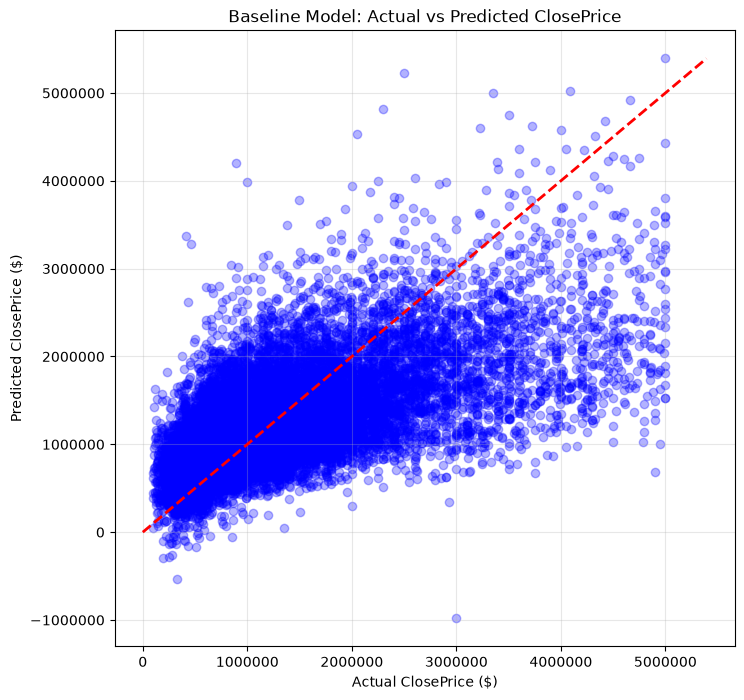

In [49]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')

# Draw the "Perfect Prediction" diagonal line
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Baseline Model: Actual vs Predicted ClosePrice')
plt.xlabel('Actual ClosePrice ($)')
plt.ylabel('Predicted ClosePrice ($)')
plt.ticklabel_format(style='plain', axis='both') # Turn off scientific notation
plt.grid(True, alpha=0.3)
plt.show()

## 8 — Check Feature Weights (Coefficients)

Because Linear Regression is so simple, we can easily see exactly how much value it  
assigned to each feature. 

**Positive coefficient:** Increases house price  
**Negative coefficient:** Decreases house price

In [50]:
# Get the coefficients from the trained model
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': model.coef_
})

# Sort from most positive impact to most negative impact
coefficients = coefficients.sort_values(by='Weight', ascending=False)
coefficients

,Feature,Weight
0,LivingArea,406920.108734
2,BathroomsTotalInteger,264533.991759
5,GarageSpaces,-2521.435887
3,LotSizeSquareFeet,-3097.690136
6,Stories,-67815.887229
7,DaysOnMarket,-68728.579375
1,BedroomsTotal,-79905.697185
4,YearBuilt,-247578.623923


## 9 — Baseline Results Summary

| Metric | Value |
|--------|-------|
| **Model** | Linear Regression |
| **Training Months** | *(see output above)* |
| **Test Months** | *(see output above)* |
| **R² Score** | *(see output above)* |

### What's next (Week 5):
Try **Decision Tree** and **Random Forest** regressors and compare their R² against this baseline.